# Actividad 2 – Análisis de Componentes Principales (PCA)
**Materia:** Minería de Datos (CD2011) · **Base:** Tarea 2 – Base alumnos prepa

Pasos seguidos (los mismos que vimos en clase):
1. Definir el objetivo del análisis
2. Cargar y preparar los datos (exploración y limpieza)
3. Estandarizar las variables (después de seleccionarlas y comparar estandarizar vs normalizar)
4. Construir la matriz de correlación
5. Calcular eigenvalues y eigenvectors
6. Seleccionar el número de componentes principales
7. Calcular los componentes principales
8. Visualizar e interpretar los resultados (scores, loadings y biplot)
9. Aplicar el PCA en el contexto del negocio (segmentación con K-Means)

## 1) Objetivo del análisis

**Problema de negocio:** una universidad quiere entender cómo evalúan los alumnos de preparatoria a las universidades que mencionan. Si los atributos evaluados (prestigio, nivel académico, oferta académica, profesores, etc.) se mueven juntos, podrían resumirse en pocas dimensiones de percepción (por ejemplo, una "calificación global" o un contraste entre atributos), y esas dimensiones servirían para orientar la comunicación, el posicionamiento de marca y para segmentar a los alumnos.

**Objetivo del PCA:** reducir las variables de evaluación a un número menor de componentes que conserven la mayor parte de la variabilidad, interpretar qué significa cada componente, visualizar la estructura de los datos y usar los componentes para segmentar.

Todavía no conozco la base, así que primero la exploro y las decisiones las tomo con base en lo que vaya encontrando.

In [1]:
# ---------- 0) Carga de librerías ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2) Carga y preparación de los datos

Al leer el archivo con la codificación por defecto (UTF-8) marca error porque tiene acentos guardados en otra codificación, por eso se usa `encoding="latin1"` (igual que en el ejemplo de clase).

In [2]:
path = "Tarea_2_Base_alumnos_prepa.csv"
df = pd.read_csv(path, encoding="latin1")

print("Filas y columnas:", df.shape)
df.head(12)

Filas y columnas: (6000, 10)


,ID_TEXT,ID_TEXT.1,CIUDAD,REGION,TIPO,UNIVERSIDAD_EVALUADA_NACIONAL,PRESTIGIO DE LA INSTITUCIÓN,NIVEL ACADÉMICO,OFERTA ACADÉMICA (CARRERAS OFERTADAS),PROFESORES
0,Entrevistado_1,Entrevistado_1,AGUASCALIENTES,BAJIO,Primera mención,UVM,10.0,8,2.0,6
1,Entrevistado_2,Entrevistado_2,MORELIA,BAJIO,Primera mención,OTRAS,7.0,8,8.0,8
2,Entrevistado_3,Entrevistado_3,MONTERREY,NORTE,Primera mención,ITESM,10.0,5,5.0,8
3,Entrevistado_4,Entrevistado_4,GUADALAJARA,BAJIO,Primera mención,OTRAS,8.0,6,6.0,9
4,Entrevistado_5,Entrevistado_5,CANCÚN,SUR,Primera mención,OTRAS,9.0,9,7.8,4
5,Entrevistado_6,Entrevistado_6,TEPIC,OCCIDENTE,Primera mención,OTRAS,8.0,5,8.0,8
6,Entrevistado_7,Entrevistado_7,GUADALAJARA,BAJIO,Primera mención,OTRAS,8.4,9,2.0,7
7,Entrevistado_8,Entrevistado_8,TEPIC,OCCIDENTE,Primera mención,OTRAS,9.0,10,6.0,7
8,Entrevistado_9,Entrevistado_9,TUXTLA GUTIÉRREZ,SUR,Primera mención,OTRAS,8.0,8,4.0,8
9,Entrevistado_10,Entrevistado_10,AGUASCALIENTES,BAJIO,Primera mención,ITESM,10.0,7,9.0,10


### 2.1 Estructura y tipos de variables

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   ID_TEXT                                6000 non-null   str    
 1   ID_TEXT.1                              6000 non-null   str    
 2   CIUDAD                                 6000 non-null   str    
 3   REGION                                 6000 non-null   str    
 4   TIPO                                   6000 non-null   str    
 5   UNIVERSIDAD_EVALUADA_NACIONAL          6000 non-null   str    
 6   PRESTIGIO DE LA INSTITUCIÓN            6000 non-null   float64
 7   NIVEL ACADÉMICO                        6000 non-null   int64  
 8   OFERTA ACADÉMICA (CARRERAS OFERTADAS)  6000 non-null   float64
 9   PROFESORES                             6000 non-null   int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 468.9 KB


Hay 6,000 registros y 10 columnas: 6 de texto (categóricas) y 4 numéricas. Las numéricas son las calificaciones que da cada alumno a la universidad que mencionó. Se ve que hay dos columnas de ID (`ID_TEXT` e `ID_TEXT.1`), lo reviso más adelante.

### 2.2 Valores faltantes

In [4]:
df.isnull().sum()

ID_TEXT                                  0
ID_TEXT.1                                0
CIUDAD                                   0
REGION                                   0
TIPO                                     0
UNIVERSIDAD_EVALUADA_NACIONAL            0
PRESTIGIO DE LA INSTITUCIÓN              0
NIVEL ACADÉMICO                          0
OFERTA ACADÉMICA (CARRERAS OFERTADAS)    0
PROFESORES                               0
dtype: int64

No hay valores nulos registrados en ninguna columna, por lo que no es necesario eliminar ni imputar filas. (Más adelante reviso si hay valores "raros" que pudieran ser faltantes ya rellenados.)

### 2.3 Duplicados

In [5]:
print("Filas completamente duplicadas:", df.duplicated().sum())
print("IDs repetidos:", df["ID_TEXT"].duplicated().sum())
print("¿ID_TEXT e ID_TEXT.1 son iguales en todas las filas?", (df["ID_TEXT"] == df["ID_TEXT.1"]).all())

Filas completamente duplicadas: 0
IDs repetidos: 0
¿ID_TEXT e ID_TEXT.1 son iguales en todas las filas? True


- No hay filas duplicadas ni IDs repetidos: cada fila es un entrevistado distinto.
- `ID_TEXT.1` es exactamente igual a `ID_TEXT`, es una columna repetida y se puede eliminar.

### 2.4 Variables categóricas

In [6]:
categoricas = df.select_dtypes(exclude="number").columns
df[categoricas].nunique()

ID_TEXT                          6000
ID_TEXT.1                        6000
CIUDAD                             35
REGION                              6
TIPO                                1
UNIVERSIDAD_EVALUADA_NACIONAL       4
dtype: int64

In [7]:
for col in ["TIPO", "REGION", "UNIVERSIDAD_EVALUADA_NACIONAL"]:
    print(df[col].value_counts(), "\n")

TIPO
Primera mención    6000
Name: count, dtype: int64 

REGION
BAJIO        2693
OCCIDENTE    1457
SUR           973
CENTRO        624
NORTE         219
ORIENTE        34
Name: count, dtype: int64 

UNIVERSIDAD_EVALUADA_NACIONAL
OTRAS      4946
ITESM       502
UVM         453
ANÁHUAC      99
Name: count, dtype: int64 



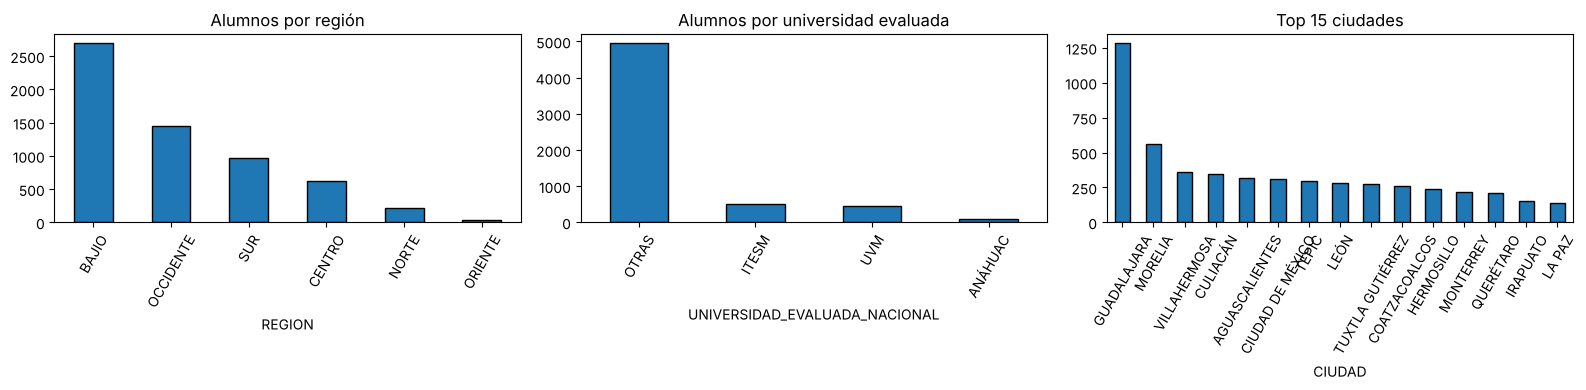

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["REGION"].value_counts().plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("Alumnos por región")
df["UNIVERSIDAD_EVALUADA_NACIONAL"].value_counts().plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Alumnos por universidad evaluada")
df["CIUDAD"].value_counts().head(15).plot(kind="bar", ax=axes[2], edgecolor="black")
axes[2].set_title("Top 15 ciudades")
for ax in axes:
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

- `TIPO` tiene un solo valor ("Primera mención") en todas las filas, entonces no aporta variabilidad y se elimina.
- `CIUDAD` tiene 35 categorías, varias con muy pocos registros; `REGION` tiene 6 (Bajío concentra casi la mitad y Oriente solo 34 alumnos) y `UNIVERSIDAD_EVALUADA_NACIONAL` tiene 4 (la gran mayoría es "OTRAS").
- Estas variables son nominales (no tienen orden ni distancia), así que no entran al PCA, pero las guardo para interpretar los resultados después.

### 2.5 Variables numéricas: rango, variabilidad y valores

In [9]:
numericas = df.select_dtypes(include="number").columns
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
PRESTIGIO DE LA INSTITUCIÓN,6000.0,8.251200,1.601876,1.0,8.0,8.4,9.0,10.0
NIVEL ACADÉMICO,6000.0,7.741833,1.943831,1.0,7.0,8.0,9.0,10.0
OFERTA ACADÉMICA (CARRERAS OFERTADAS),6000.0,7.285900,2.225782,1.0,7.0,7.8,8.0,10.0
PROFESORES,6000.0,7.779500,1.778409,1.0,8.0,8.0,8.0,10.0


In [10]:
for col in numericas:
    print(df[col].value_counts().sort_index(), "\n")

PRESTIGIO DE LA INSTITUCIÓN
1.0       38
2.0       34
3.0       36
4.0       70
5.0      191
6.0      377
7.0      583
8.0      780
8.4     1663
9.0      774
10.0    1454
Name: count, dtype: int64 

NIVEL ACADÉMICO
1       85
2       59
3      134
4      197
5      294
6      416
7      428
8     2656
9      462
10    1269
Name: count, dtype: int64 

OFERTA ACADÉMICA (CARRERAS OFERTADAS)
1.0      222
2.0      134
3.0      187
4.0      247
5.0      264
6.0      331
7.0      330
7.8     2633
8.0      349
9.0      299
10.0    1004
Name: count, dtype: int64 

PROFESORES
1       80
2       61
3      107
4      158
5      210
6      304
7      402
8     3282
9      382
10    1014
Name: count, dtype: int64 



Las cuatro variables están en una escala de 1 a 10 y todos los valores están dentro de ese rango. Sin embargo aparecen cosas que hay que revisar:

- En `PRESTIGIO DE LA INSTITUCIÓN` aparece el valor **8.4** y en `OFERTA ACADÉMICA` el valor **7.8**. Son los únicos valores no enteros en una escala de enteros y además son los más frecuentes.
- En `NIVEL ACADÉMICO` y `PROFESORES` el valor 8 tiene muchísimos más casos que el 7 y el 9.

Esto parece un relleno de valores faltantes (alguien ya puso un valor fijo donde no había respuesta). Lo cuantifico:

In [11]:
pd.DataFrame({
    "% valores no enteros": (df[numericas] % 1 != 0).mean() * 100,
    "% del valor más frecuente": df[numericas].apply(lambda c: c.value_counts(normalize=True).max() * 100)
}).round(1)

,% valores no enteros,% del valor más frecuente
PRESTIGIO DE LA INSTITUCIÓN,27.7,27.7
NIVEL ACADÉMICO,0.0,44.3
OFERTA ACADÉMICA (CARRERAS OFERTADAS),43.9,43.9
PROFESORES,0.0,54.7


Prestigio tiene 27.7% de valores 8.4 y Oferta académica 43.9% de valores 7.8. Para Nivel académico y Profesores no se puede saber cuáles 8 son reales y cuáles rellenados, pero el pico es muy marcado (44% y 55%). Esto importa para el PCA porque un valor constante repetido **reduce la varianza y debilita las correlaciones** entre variables. La decisión de qué hacer la tomo en la limpieza.

### 2.6 Distribuciones y valores atípicos

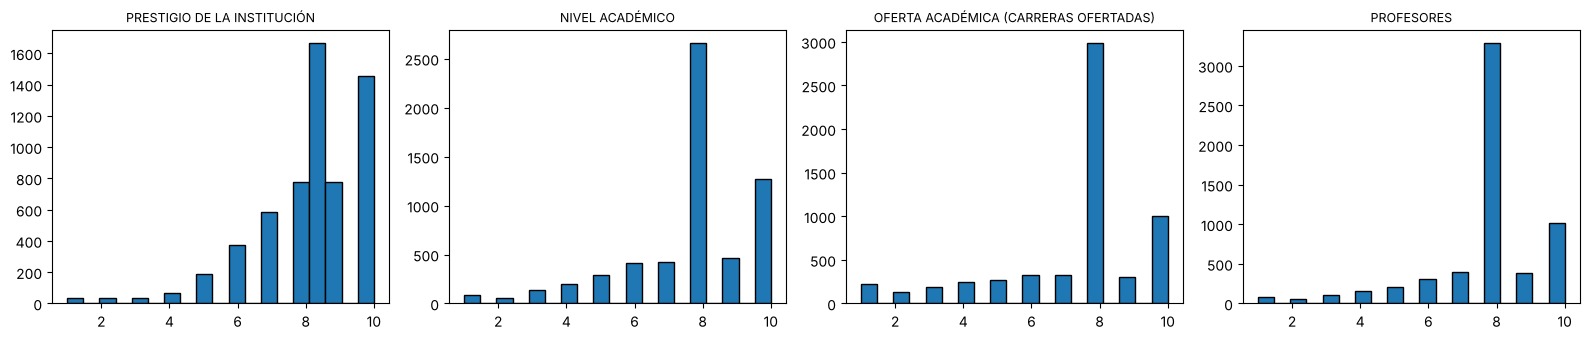

Asimetría:
PRESTIGIO DE LA INSTITUCIÓN             -1.51
NIVEL ACADÉMICO                         -1.24
OFERTA ACADÉMICA (CARRERAS OFERTADAS)   -1.21
PROFESORES                              -1.53
dtype: float64


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, numericas):
    ax.hist(df[col], bins=19, edgecolor="black")
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

print("Asimetría:")
print(df[numericas].skew().round(2))

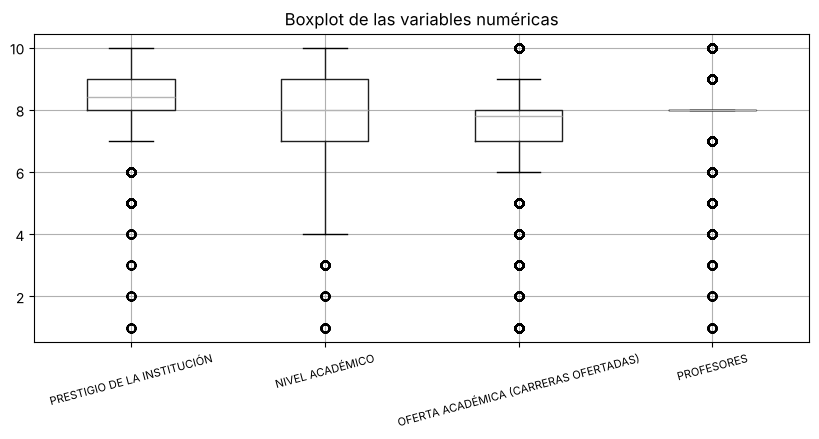

PRESTIGIO DE LA INSTITUCIÓN: Q1 = 8.0, Q3 = 9.0, IQR = 1.0, atípicos = 746
NIVEL ACADÉMICO: Q1 = 7.0, Q3 = 9.0, IQR = 2.0, atípicos = 278
OFERTA ACADÉMICA (CARRERAS OFERTADAS): Q1 = 7.0, Q3 = 8.0, IQR = 1.0, atípicos = 2058
PROFESORES: Q1 = 8.0, Q3 = 8.0, IQR = 0.0, atípicos = 2718


In [13]:
plt.figure(figsize=(10, 4))
df[numericas].boxplot()
plt.xticks(rotation=15, fontsize=8)
plt.title("Boxplot de las variables numéricas")
plt.show()

# Conteo de atípicos con el criterio del rango intercuartílico (IQR)
for col in numericas:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    atipicos = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col}: Q1 = {q1}, Q3 = {q3}, IQR = {iqr:.1f}, atípicos = {atipicos}")

Las cuatro variables tienen asimetría negativa: la mayoría de los alumnos califica alto (7 a 10) y pocos califican bajo.

El criterio IQR marca muchísimos "atípicos" (2,718 en Profesores y 2,058 en Oferta académica). Esto no es porque haya valores extremos, sino porque el valor repetido (8 o 7.8) concentra tanto los datos que el rango intercuartílico se vuelve muy pequeño (en Profesores Q1 = Q3 = 8, entonces IQR = 0 y todo lo que no sea 8 sale como atípico). Es otro síntoma del relleno de valores. Las calificaciones bajas **no son errores**: son respuestas válidas dentro de la escala 1–10 y representan a los alumnos con mala percepción, que es información útil. Por eso no se eliminan. Como la escala está acotada, no hay valores imposibles que puedan "jalar" a los componentes.

### 2.7 Limpieza

Con lo que encontré en la exploración:
- Elimino `ID_TEXT.1` (copia exacta de `ID_TEXT`) y `TIPO` (valor constante).
- No hay nulos ni duplicados, así que no se eliminan filas por eso.
- Los tipos de datos son correctos (numéricas como número y categóricas como texto), no hace falta convertir.
- Renombro las variables numéricas con nombres cortos para que las tablas y gráficas se lean mejor.

In [14]:
df_limpio = df.drop(columns=["ID_TEXT.1", "TIPO"])
df_limpio = df_limpio.rename(columns={
    "PRESTIGIO DE LA INSTITUCIÓN": "Prestigio",
    "NIVEL ACADÉMICO": "Nivel_academico",
    "OFERTA ACADÉMICA (CARRERAS OFERTADAS)": "Oferta_academica",
    "PROFESORES": "Profesores",
    "UNIVERSIDAD_EVALUADA_NACIONAL": "Universidad"
})
variables = ["Prestigio", "Nivel_academico", "Oferta_academica", "Profesores"]

shape_report = pd.DataFrame({
    "métrica": ["filas", "columnas originales", "columnas después de limpiar", "variables numéricas"],
    "valor": [df_limpio.shape[0], df.shape[1], df_limpio.shape[1], len(variables)]
})
print(shape_report)
df_limpio.head()

                       métrica  valor
0                        filas   6000
1          columnas originales     10
2  columnas después de limpiar      8
3          variables numéricas      4


,ID_TEXT,CIUDAD,REGION,Universidad,Prestigio,Nivel_academico,Oferta_academica,Profesores
0,Entrevistado_1,AGUASCALIENTES,BAJIO,UVM,10.0,8,2.0,6
1,Entrevistado_2,MORELIA,BAJIO,OTRAS,7.0,8,8.0,8
2,Entrevistado_3,MONTERREY,NORTE,ITESM,10.0,5,5.0,8
3,Entrevistado_4,GUADALAJARA,BAJIO,OTRAS,8.0,6,6.0,9
4,Entrevistado_5,CANCÚN,SUR,OTRAS,9.0,9,7.8,4


**¿Qué hago con los valores que parecen rellenados?** Tengo dos opciones: quedarme con todas las filas o quitar las que tienen 8.4 en Prestigio o 7.8 en Oferta. Quitar esas filas eliminaría más de la mitad de la base, así que antes de decidir comparo si las correlaciones cambian.

In [15]:
sin_relleno = (df_limpio["Prestigio"] % 1 == 0) & (df_limpio["Oferta_academica"] % 1 == 0)
print("Filas sin valores rellenados:", sin_relleno.sum(), "de", len(df_limpio))

print("\nCorrelaciones con todas las filas:")
print(df_limpio[variables].corr().round(3))
print("\nCorrelaciones solo con filas sin relleno:")
print(df_limpio.loc[sin_relleno, variables].corr().round(3))

Filas sin valores rellenados: 2385 de 6000

Correlaciones con todas las filas:
                  Prestigio  Nivel_academico  Oferta_academica  Profesores
Prestigio             1.000           -0.000             0.020       0.002
Nivel_academico      -0.000            1.000             0.017       0.025
Oferta_academica      0.020            0.017             1.000       0.005
Profesores            0.002            0.025             0.005       1.000

Correlaciones solo con filas sin relleno:
                  Prestigio  Nivel_academico  Oferta_academica  Profesores
Prestigio             1.000           -0.015             0.028       0.002
Nivel_academico      -0.015            1.000             0.013       0.027
Oferta_academica      0.028            0.013             1.000       0.000
Profesores            0.002            0.027             0.000       1.000


Eliminar las filas con relleno dejaría solo 2,385 registros (se perdería el 60% de la base) y las correlaciones prácticamente no cambian: en los dos casos están entre -0.02 y 0.03. Por lo tanto **conservo las 6,000 filas** y dejo anotado como limitación que una parte de los valores probablemente fue imputada. Más adelante reviso si los resultados del PCA se mantienen con la base reducida.

### 2.8 Selección de variables

**Criterio conceptual:**
- **Se incluyen** las 4 calificaciones (Prestigio, Nivel académico, Oferta académica y Profesores): son numéricas, miden atributos de percepción de la universidad y están en la misma escala, que es lo que el PCA necesita.
- **Se excluyen** `ID_TEXT` (solo identifica al alumno), y `CIUDAD`, `REGION` y `Universidad` porque son nominales; convertirlas en dummies metería columnas 0/1 que no representan una distancia real y distorsionarían el PCA. Las uso después para interpretar.

**Criterio cuantitativo:** el PCA solo sirve si las variables están correlacionadas, así que reviso su relación con una matriz de dispersión y con la matriz de correlación.

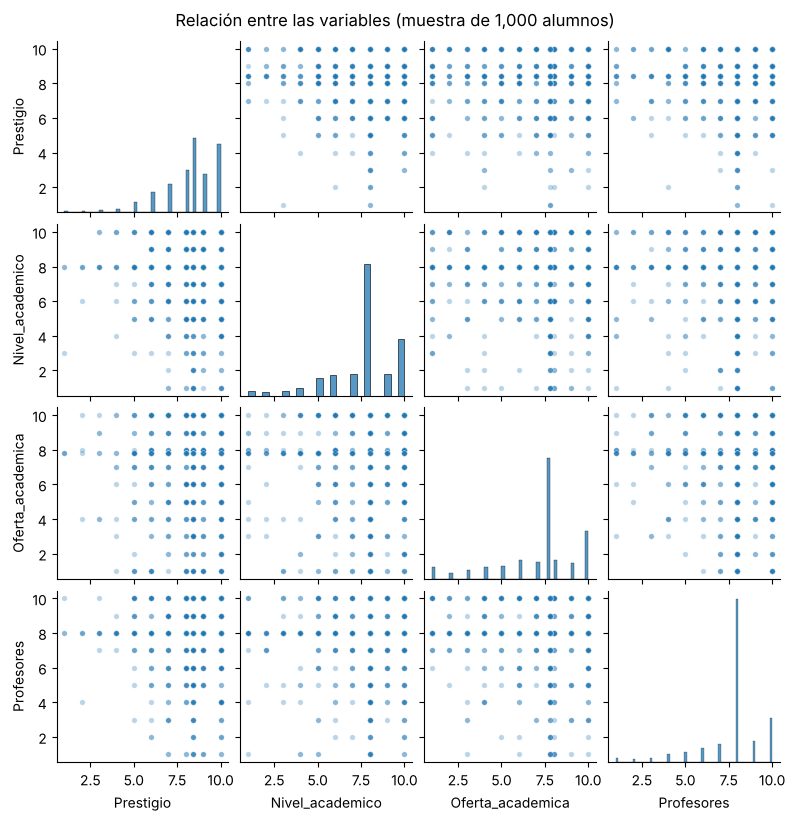

In [16]:
X = df_limpio[variables]

sns.pairplot(X.sample(1000, random_state=42), plot_kws={"alpha": 0.3, "s": 15}, height=2)
plt.suptitle("Relación entre las variables (muestra de 1,000 alumnos)", y=1.02)
plt.show()

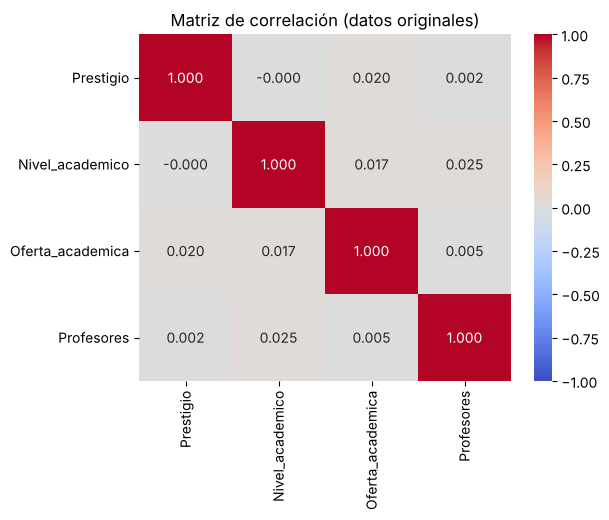

In [17]:
plt.figure(figsize=(6, 4.5))
sns.heatmap(X.corr(), annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación (datos originales)")
plt.show()

En el pairplot no se ve ninguna tendencia (las nubes no tienen forma diagonal; las líneas y columnas de puntos son por los valores discretos y el relleno) y todas las correlaciones son prácticamente cero (la mayor es 0.025). Esto ya es una señal de alerta: si las variables no comparten información, el PCA no va a poder "juntarlas" en pocos componentes. Para comprobarlo formalmente uso la **prueba de esfericidad de Bartlett**, que evalúa si la matriz de correlación es distinta de la matriz identidad (H0: las variables no están correlacionadas).

In [18]:
n, p = X.shape
R = X.corr().values
chi2 = -(n - 1 - (2 * p + 5) / 6) * np.log(np.linalg.det(R))
gl = p * (p - 1) / 2
p_valor = stats.chi2.sf(chi2, gl)
print(f"Chi-cuadrada = {chi2:.2f}, gl = {gl:.0f}, p-valor = {p_valor:.3f}")

Chi-cuadrada = 7.90, gl = 6, p-valor = 0.245


El p-valor es 0.245 (> 0.05), así que **no se rechaza H0**: estadísticamente no hay evidencia de que las variables estén correlacionadas, aun con 6,000 observaciones. Aun así hago el PCA porque es lo que pide la actividad y porque el propio resultado (que no hay reducción posible) también es un hallazgo. Las 4 variables se conservan porque son las únicas que pueden entrar, y ninguna es redundante con otra.

## 3) Estandarizar las variables (¿estandarizar o normalizar?)

En clase vimos que muchos modelos funcionan con cualquiera de las dos opciones y conviene compararlas, y que para clustering, PCA y modelos lineales se recomienda comenzar con estandarización (para clasificación bayesiana, árboles o redes neuronales no se requiere). Como el PCA se basa en varianzas, primero reviso si las variables tienen varianzas parecidas:

In [19]:
X.agg(["min", "max", "std", "var"]).T.round(2)

,min,max,std,var
Prestigio,1.0,10.0,1.60,2.57
Nivel_academico,1.0,10.0,1.94,3.78
Oferta_academica,1.0,10.0,2.23,4.95
Profesores,1.0,10.0,1.78,3.16


Las cuatro tienen el mismo rango (1 a 10), pero la varianza de Oferta académica (4.95) es casi el doble que la de Prestigio (2.57). Comparo qué pasa con el PCA en tres casos: sin escalar, normalizado (Min-Max) y estandarizado (Z-score).

Sin escalar
  % varianza por componente: [34.3 26.2 21.8 17.7]
  Cargas de PC1: {'Prestigio': 0.03, 'Nivel_academico': 0.06, 'Oferta_academica': 1.0, 'Profesores': 0.01}
Normalizado (Min-Max)
  % varianza por componente: [34.3 26.2 21.8 17.7]
  Cargas de PC1: {'Prestigio': 0.03, 'Nivel_academico': 0.06, 'Oferta_academica': 1.0, 'Profesores': 0.01}
Estandarizado (Z-score)
  % varianza por componente: [25.9 25.3 24.6 24.2]
  Cargas de PC1: {'Prestigio': 0.32, 'Nivel_academico': 0.6, 'Oferta_academica': 0.53, 'Profesores': 0.51}


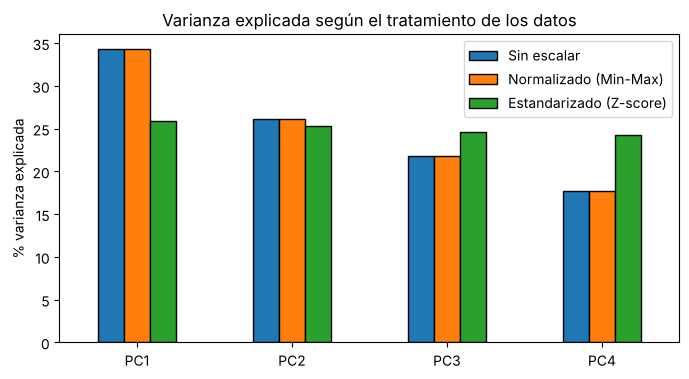

In [20]:
opciones = {
    "Sin escalar": X.values,
    "Normalizado (Min-Max)": MinMaxScaler().fit_transform(X),
    "Estandarizado (Z-score)": StandardScaler().fit_transform(X)
}

comparacion = {}
for nombre, datos in opciones.items():
    pca_prueba = PCA().fit(datos)
    comparacion[nombre] = pca_prueba.explained_variance_ratio_ * 100
    print(nombre)
    print("  % varianza por componente:", (pca_prueba.explained_variance_ratio_ * 100).round(1))
    print("  Cargas de PC1:", pd.Series(pca_prueba.components_[0], index=variables).round(2).to_dict())

pd.DataFrame(comparacion, index=["PC1", "PC2", "PC3", "PC4"]).plot(kind="bar", figsize=(8, 4), edgecolor="black")
plt.ylabel("% varianza explicada")
plt.title("Varianza explicada según el tratamiento de los datos")
plt.xticks(rotation=0)
plt.show()

- **Sin escalar** y **Min-Max** dan exactamente el mismo resultado: como todas las variables van de 1 a 10, Min-Max divide a todas entre lo mismo y no corrige las diferencias de varianza.
- En esos dos casos PC1 es prácticamente solo **Oferta académica** (carga 1.00) y cada componente termina siendo una sola variable, ordenadas de mayor a menor varianza. Es decir, el PCA solo estaría reflejando qué variable tiene más dispersión, no una relación entre variables.
- Con **estandarización** cada variable tiene varianza 1 y todas contribuyen igual, por lo que los componentes dependen de las correlaciones y no de la escala.

**Decisión: estandarizar (Z-score).** Esto equivale a hacer el PCA sobre la matriz de correlación. La implicación es que cada variable "pesa" lo mismo en el análisis.

      Prestigio  Nivel_academico  Oferta_academica  Profesores
mean       -0.0              0.0               0.0         0.0
std         1.0              1.0               1.0         1.0


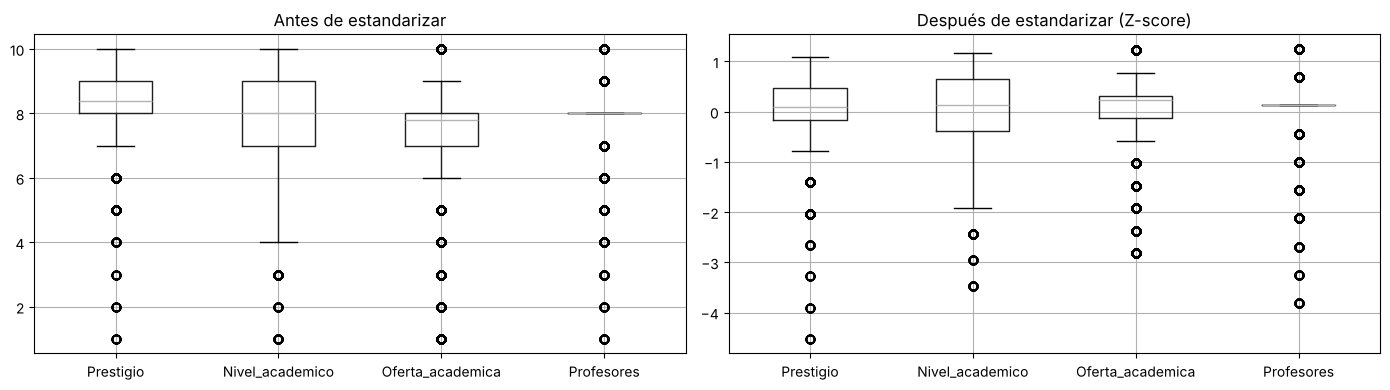

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaled_df = pd.DataFrame(X_scaled, columns=variables)

# Comprobación: media 0 y desviación estándar 1
print(scaled_df.agg(["mean", "std"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
X.boxplot(ax=axes[0])
axes[0].set_title("Antes de estandarizar")
scaled_df.boxplot(ax=axes[1])
axes[1].set_title("Después de estandarizar (Z-score)")
plt.tight_layout()
plt.show()

Después de estandarizar todas las variables quedan centradas en 0 y con la misma dispersión, así que ninguna domina el PCA por su escala.

## 4) Matriz de correlación

In [22]:
corr_matrix = np.corrcoef(X_scaled, rowvar=False)
corr_df = pd.DataFrame(corr_matrix, index=variables, columns=variables)
corr_df.round(3)

,Prestigio,Nivel_academico,Oferta_academica,Profesores
Prestigio,1.000,-0.000,0.020,0.002
Nivel_academico,-0.000,1.000,0.017,0.025
Oferta_academica,0.020,0.017,1.000,0.005
Profesores,0.002,0.025,0.005,1.000


Es la misma matriz que con los datos originales (la correlación no depende de la escala), lo que confirma que el PCA sobre datos estandarizados es un PCA sobre la matriz de correlación.

## 5) Eigenvalues y eigenvectors

In [23]:
eig_vals, eig_vecs = np.linalg.eigh(corr_matrix)   # eigh porque la matriz de correlación es simétrica
idx_sorted = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[idx_sorted]
eig_vecs_sorted = eig_vecs[:, idx_sorted]

explained_ratio_eig = eig_vals_sorted / eig_vals_sorted.sum()
cum_explained_eig = np.cumsum(explained_ratio_eig)

eig_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(p)],
    "eigenvalue": eig_vals_sorted,
    "explained_variance_ratio": explained_ratio_eig,
    "cumulative_explained_variance": cum_explained_eig
})
print(eig_summary.round(4))

print("\nEigenvectors (columnas = componentes):")
pd.DataFrame(eig_vecs_sorted, index=variables, columns=eig_summary["PC"]).round(3)

    PC  eigenvalue  explained_variance_ratio  cumulative_explained_variance
0  PC1      1.0358                    0.2590                         0.2590
1  PC2      1.0116                    0.2529                         0.5119
2  PC3      0.9833                    0.2458                         0.7577
3  PC4      0.9693                    0.2423                         1.0000

Eigenvectors (columnas = componentes):


PC,PC1,PC2,PC3,PC4
Prestigio,-0.319,0.682,0.553,0.357
Nivel_academico,-0.599,-0.359,-0.317,0.642
Oferta_academica,-0.534,0.436,-0.516,-0.509
Profesores,-0.505,-0.465,0.572,-0.449


Con datos estandarizados la varianza total es 4 (una unidad por variable), así que un eigenvalue de 1 significa que el componente explica lo mismo que una sola variable original. Aquí los cuatro eigenvalues están entre 0.97 y 1.04 y cada componente explica entre 24% y 26%: **ningún componente concentra la varianza**, que es justo lo que se esperaba con correlaciones cercanas a cero.

## 6) Seleccionar el número de componentes

Uso los dos criterios de clase y los contrasto con otros dos:
- **Kaiser:** conservar componentes con eigenvalue > 1.
- **Varianza acumulada ≥ 75%.**
- **Scree plot:** buscar un "codo".
- **Análisis paralelo:** comparar cada eigenvalue con el que saldría de datos aleatorios sin ninguna correlación del mismo tamaño (6,000 × 4). Solo vale la pena un componente si su eigenvalue es mayor que el del azar.

In [24]:
n_kaiser = int((eig_vals_sorted > 1.0).sum())
n_cum = int(np.argmax(cum_explained_eig >= 0.75) + 1)
n_components = max(n_kaiser, n_cum)     # regla usada en clase

# Análisis paralelo: 100 bases aleatorias del mismo tamaño
np.random.seed(42)
eig_azar = []
for i in range(100):
    datos_azar = np.random.normal(size=(n, p))
    eig_azar.append(np.linalg.eigvalsh(np.corrcoef(datos_azar, rowvar=False))[::-1])
eig_azar_95 = np.percentile(eig_azar, 95, axis=0)
n_paralelo = int((eig_vals_sorted > eig_azar_95).sum())

selection_report = pd.DataFrame({
    "criterio": ["Kaiser (>1.0)", "Acumulada >= 0.75", "Análisis paralelo", "n_components elegido"],
    "valor": [n_kaiser, n_cum, n_paralelo, n_components]
})
print(selection_report)

pd.DataFrame({"eigenvalue real": eig_vals_sorted, "eigenvalue azar (p95)": eig_azar_95},
             index=eig_summary["PC"]).round(3)

               criterio  valor
0         Kaiser (>1.0)      2
1     Acumulada >= 0.75      3
2     Análisis paralelo      0
3  n_components elegido      3


,eigenvalue real,eigenvalue azar (p95)
PC,,
PC1,1.036,1.044
PC2,1.012,1.018
PC3,0.983,1.001
PC4,0.969,0.986


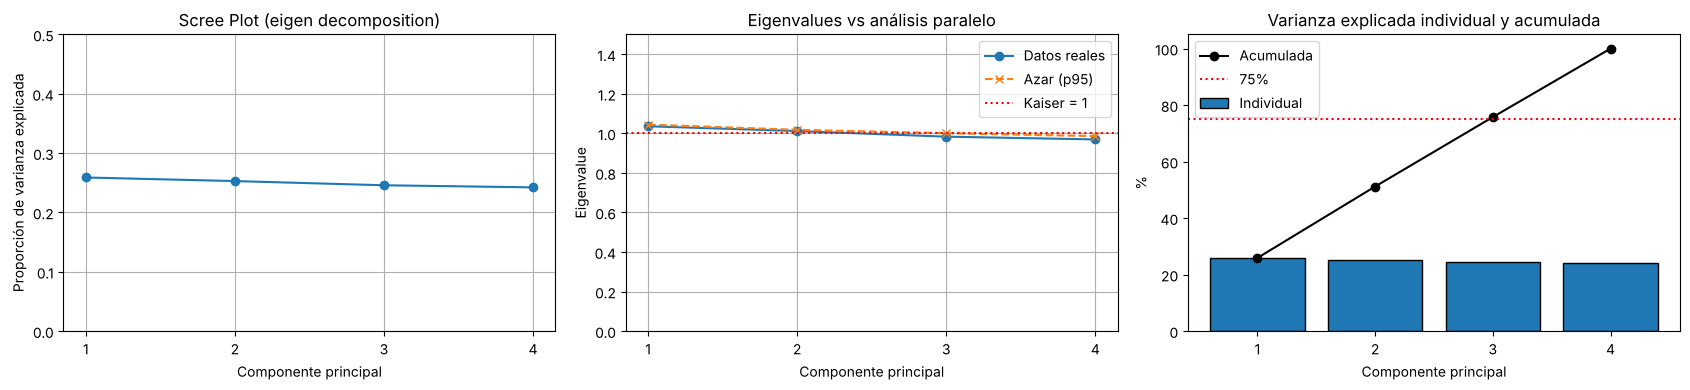

In [25]:
componentes = np.arange(1, p + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(componentes, explained_ratio_eig, marker="o")
axes[0].set_title("Scree Plot (eigen decomposition)")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Proporción de varianza explicada")
axes[0].set_ylim(0, 0.5)
axes[0].set_xticks(componentes)
axes[0].grid(True)

axes[1].plot(componentes, eig_vals_sorted, marker="o", label="Datos reales")
axes[1].plot(componentes, eig_azar_95, marker="x", linestyle="--", label="Azar (p95)")
axes[1].axhline(1, color="red", linestyle=":", label="Kaiser = 1")
axes[1].set_title("Eigenvalues vs análisis paralelo")
axes[1].set_xlabel("Componente principal")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_ylim(0, 1.5)
axes[1].set_xticks(componentes)
axes[1].legend()
axes[1].grid(True)

axes[2].bar(componentes, explained_ratio_eig * 100, label="Individual", edgecolor="black")
axes[2].plot(componentes, cum_explained_eig * 100, marker="o", color="black", label="Acumulada")
axes[2].axhline(75, color="red", linestyle=":", label="75%")
axes[2].set_title("Varianza explicada individual y acumulada")
axes[2].set_xlabel("Componente principal")
axes[2].set_ylabel("%")
axes[2].set_xticks(componentes)
axes[2].legend()

plt.tight_layout()
plt.show()

Los criterios no coinciden, y eso refleja la ambigüedad del caso:

| Criterio | Componentes | Comentario |
|---|---|---|
| Kaiser | 2 | PC1 y PC2 apenas pasan de 1 (1.036 y 1.012) |
| Varianza acumulada ≥ 75% | 3 | Hay que conservar 3 de 4 dimensiones |
| Scree plot | — | La línea es casi plana, no hay codo |
| Análisis paralelo | 0 | Ningún eigenvalue supera lo que da el azar |

**Decisión:** siguiendo la regla de clase (el máximo entre Kaiser y el 75% acumulado) conservo **3 componentes**, que explican el 75.8% de la varianza. Hay que tener claro lo que esto implica: pasar de 4 variables a 3 componentes casi no simplifica nada, y el análisis paralelo indica que ninguno de los componentes es distinto de lo que se obtendría con datos aleatorios. Si solo se usara Kaiser se quedarían 2 (51% de varianza), lo cual perdería casi la mitad de la información. Para graficar uso PC1–PC2 (el plano con más varianza) y también PC1–PC3.

## 7) Calcular los componentes principales

In [26]:
pca = PCA(n_components=n_components, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

explained_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)
pcs = [f"PC{i+1}" for i in range(n_components)]

pca_summary = pd.DataFrame({
    "PC": pcs,
    "eigenvalue": pca.explained_variance_,
    "explained_variance_ratio": explained_ratio,
    "cumulative_explained_variance": cum_explained
})
pca_summary.round(4)

,PC,eigenvalue,explained_variance_ratio,cumulative_explained_variance
0,PC1,1.0360,0.2590,0.2590
1,PC2,1.0118,0.2529,0.5119
2,PC3,0.9834,0.2458,0.7577


Los eigenvalues y la varianza explicada de `sklearn` coinciden con los que calculé a mano con la matriz de correlación, así que el cálculo es consistente. (En el cálculo a mano PC1 salió con todos los signos negativos y en `sklearn` positivos: el signo de un eigenvector es arbitrario, lo que importa es el signo relativo entre variables dentro del mismo componente.)

In [27]:
# Cargas (loadings) y % de contribución de cada variable a cada componente
loadings = pd.DataFrame(pca.components_.T, index=variables, columns=pcs)
contribucion = (loadings ** 2) * 100
print("Loadings:")
print(loadings.round(3))
print("\n% de contribución:")
print(contribucion.round(1))

# Guardar los scores
pca_scores_df = pd.DataFrame(X_pca, columns=pcs)
pca_scores_df.to_csv("Alumnos_PCA_scores.csv", index=False)
pca_scores_df.head()

Loadings:
                    PC1    PC2    PC3
Prestigio         0.319  0.682  0.553
Nivel_academico   0.599 -0.359 -0.317
Oferta_academica  0.534  0.436 -0.516
Profesores        0.505 -0.465  0.572

% de contribución:
                   PC1   PC2   PC3
Prestigio         10.1  46.5  30.6
Nivel_academico   35.8  12.9  10.0
Oferta_academica  28.5  19.0  26.6
Profesores        25.5  21.6  32.7


,PC1,PC2,PC3
0,-1.345720,0.127132,1.214921
1,0.064572,-0.498287,-0.568648
2,-0.982226,0.745912,1.651899
3,-0.548013,-0.356010,0.888323
4,-0.414205,1.174957,-1.282099


## 8) Visualizar e interpretar los resultados

### 8.1 Loadings

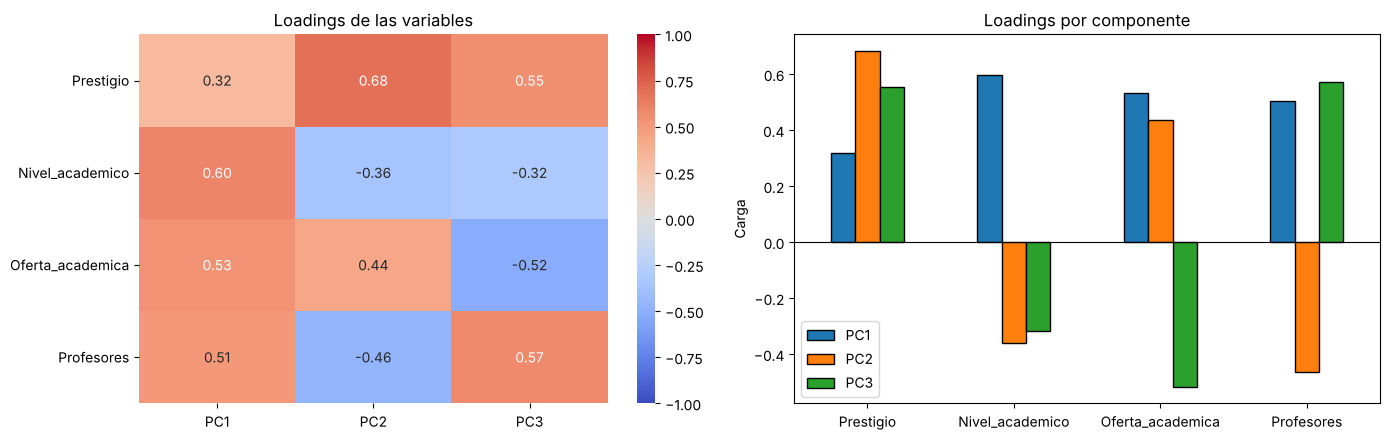

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Loadings de las variables")

loadings.plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Loadings por componente")
axes[1].set_ylabel("Carga")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Interpretación de las cargas:**

- **PC1 (25.9%) – "Valoración académica general":** todas las cargas son positivas. Las que más contribuyen son Nivel académico (0.60), Oferta académica (0.53) y Profesores (0.51); Prestigio aporta menos (0.32). Un alumno con puntaje alto en PC1 califica bien a la universidad en general, sobre todo en lo académico.
- **PC2 (25.3%) – "Imagen y oferta vs. calidad docente":** es un contraste. Prestigio (+0.68) y Oferta académica (+0.44) van del lado positivo, y Profesores (-0.46) y Nivel académico (-0.36) del lado negativo. Valores positivos indican alumnos que califican mejor el prestigio y la oferta que la parte académica/docente.
- **PC3 (24.6%) – "Prestigio y profesores vs. oferta y nivel":** otro contraste. Profesores (+0.57) y Prestigio (+0.55) del lado positivo, y Oferta académica (-0.52) y Nivel académico (-0.32) del lado negativo. Valores positivos indican alumnos que valoran más la reputación y los profesores que el catálogo de carreras.

### 8.2 Círculo de correlaciones

Para ver qué tan bien representada está cada variable en el plano, calculo la correlación entre cada variable y cada componente (carga × raíz del eigenvalue). Si una flecha llega cerca del círculo, la variable está bien representada en ese plano.

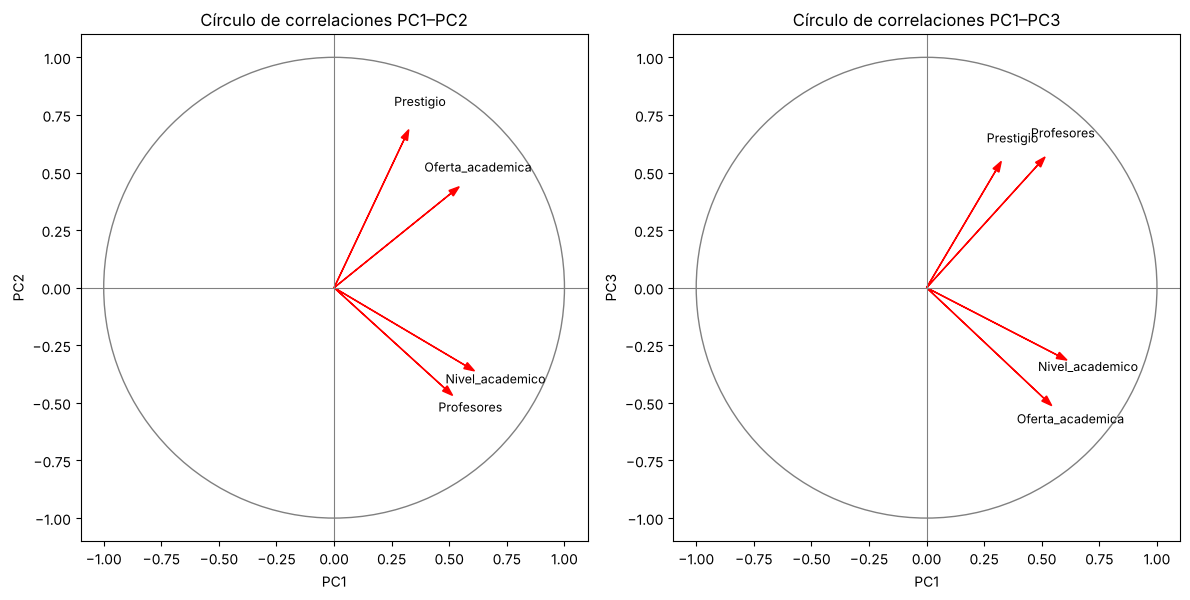

Calidad de representación en PC1–PC2 (cos²):
Prestigio           0.58
Nivel_academico     0.50
Oferta_academica    0.49
Profesores          0.48
dtype: float64


In [29]:
corr_var_pc = loadings * np.sqrt(pca.explained_variance_)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (a, b) in zip(axes, [("PC1", "PC2"), ("PC1", "PC3")]):
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="gray"))
    for var in variables:
        ax.arrow(0, 0, corr_var_pc.loc[var, a], corr_var_pc.loc[var, b],
                 color="red", head_width=0.03, length_includes_head=True)
        ax.text(corr_var_pc.loc[var, a] * 1.15, corr_var_pc.loc[var, b] * 1.15, var, ha="center", fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f"Círculo de correlaciones {a}–{b}")
plt.tight_layout()
plt.show()

print("Calidad de representación en PC1–PC2 (cos²):")
print((corr_var_pc[["PC1", "PC2"]] ** 2).sum(axis=1).round(2))

Ninguna flecha llega cerca del círculo: en el plano PC1–PC2 cada variable tiene una calidad de representación (cos²) de solo ~0.5, es decir, la mitad de la información de cada variable queda fuera del plano. Esto confirma que con 2 dimensiones no se representa bien ninguna variable.

### 8.3 Scores

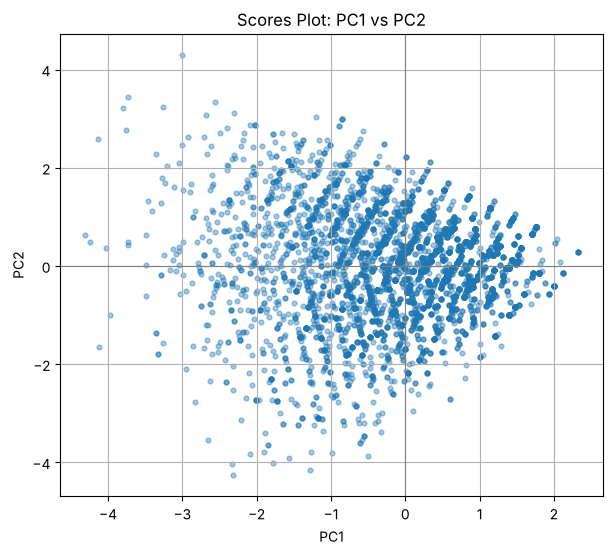

In [30]:
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=12, alpha=0.4)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Scores Plot: PC1 vs PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

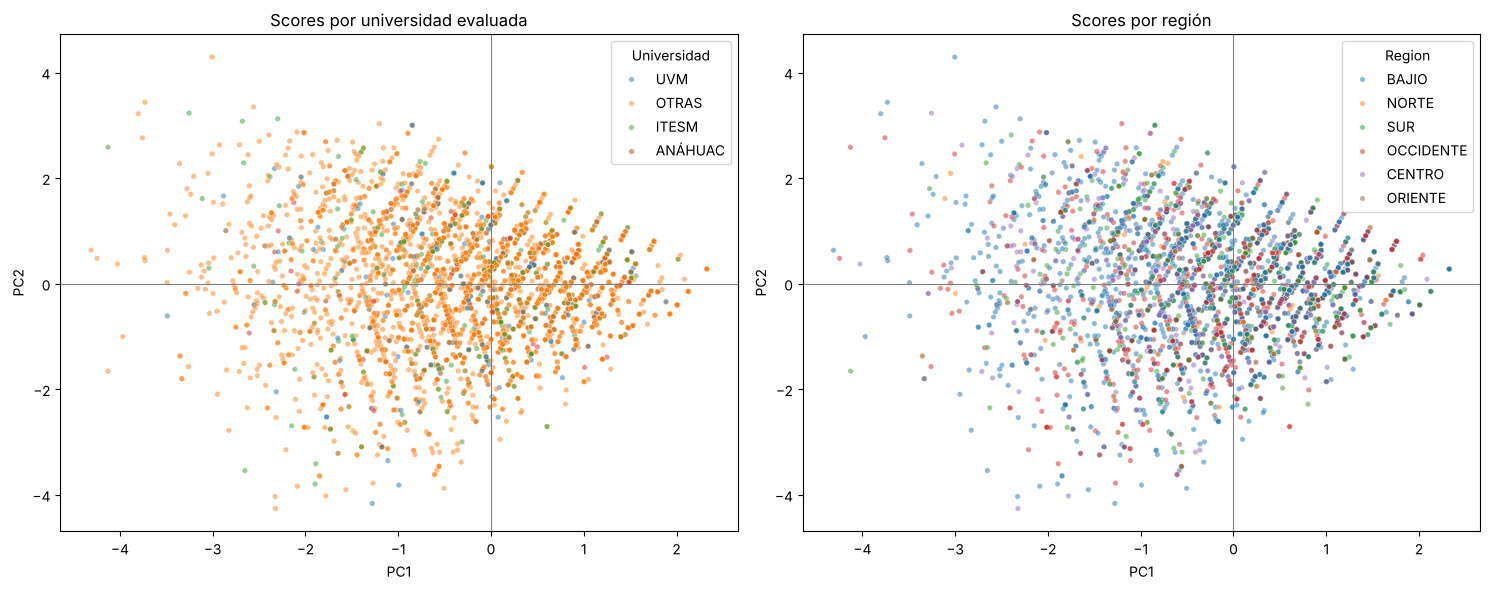

Promedio de los scores por universidad:
               PC1    PC2    PC3
Universidad                     
ANÁHUAC      0.066  0.055  0.111
ITESM       -0.039 -0.000 -0.025
OTRAS       -0.010 -0.001 -0.002
UVM          0.141 -0.005  0.025

Promedio de los scores por región:
             PC1    PC2    PC3
Region                        
BAJIO     -0.074 -0.008 -0.003
CENTRO    -0.032  0.040 -0.008
NORTE      0.013  0.049  0.057
OCCIDENTE  0.015 -0.057 -0.054
ORIENTE    0.116 -0.220 -0.093
SUR        0.195  0.078  0.084


In [31]:
scores = pca_scores_df.copy()
scores["Universidad"] = df_limpio["Universidad"].values
scores["Region"] = df_limpio["REGION"].values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=scores, x="PC1", y="PC2", hue="Universidad", s=15, alpha=0.5, ax=axes[0])
axes[0].set_title("Scores por universidad evaluada")
sns.scatterplot(data=scores, x="PC1", y="PC2", hue="Region", s=15, alpha=0.5, ax=axes[1])
axes[1].set_title("Scores por región")
for ax in axes:
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Promedio de los scores por universidad:")
print(scores.groupby("Universidad")[pcs].mean().round(3))
print("\nPromedio de los scores por región:")
print(scores.groupby("Region")[pcs].mean().round(3))

- Los puntos forman **una sola nube continua**, sin grupos separados. Es más densa a la derecha (alumnos que califican alto en todo) y tiene una cola hacia la izquierda (pocos alumnos con calificaciones bajas), lo que coincide con la asimetría negativa de la exploración.
- Las universidades y las regiones están completamente mezcladas. Los promedios de los scores por grupo son muy cercanos a 0 (los scores tienen desviación de ~1), así que **ni la universidad evaluada ni la región diferencian a los alumnos** en estos componentes. (Oriente tiene los valores más alejados, pero solo son 34 alumnos.)
- Las "líneas" diagonales de puntos se deben a que las calificaciones son enteros de 1 a 10 más los valores rellenados, no a una estructura real.

### 8.4 Biplot

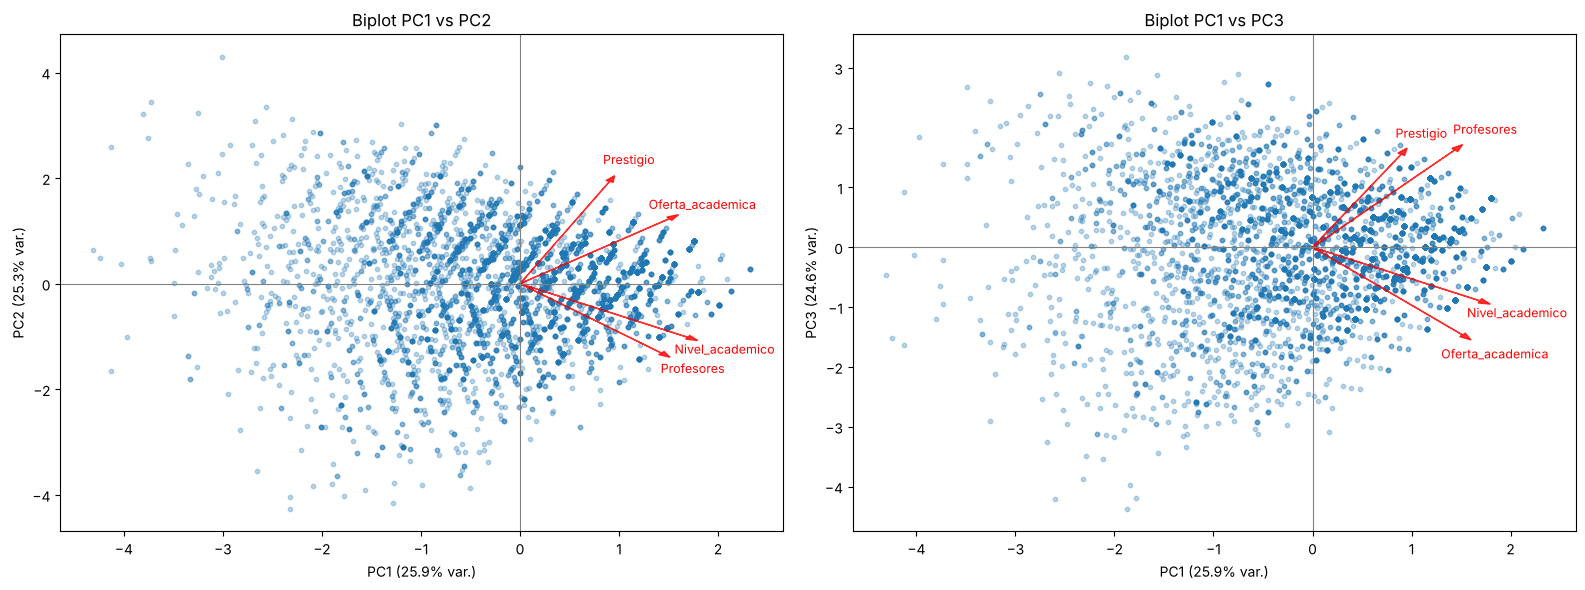

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
arrow_scale = 3.0

for ax, (i, j) in zip(axes, [(0, 1), (0, 2)]):
    # 1) Puntos (observaciones proyectadas)
    ax.scatter(X_pca[:, i], X_pca[:, j], s=10, alpha=0.3)
    # 2) Flechas (vectores de variables / loadings)
    for k, var in enumerate(variables):
        ax.arrow(0, 0, loadings.iloc[k, i] * arrow_scale, loadings.iloc[k, j] * arrow_scale,
                 color="red", alpha=0.8, head_width=0.08, length_includes_head=True)
        ax.text(loadings.iloc[k, i] * arrow_scale * 1.15, loadings.iloc[k, j] * arrow_scale * 1.15,
                var, color="red", ha="center", va="center", fontsize=9)
    # 3) Decoración
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel(f"PC{i+1} ({explained_ratio[i]*100:.1f}% var.)")
    ax.set_ylabel(f"PC{j+1} ({explained_ratio[j]*100:.1f}% var.)")
    ax.set_title(f"Biplot PC{i+1} vs PC{j+1}")

plt.tight_layout()
plt.show()

- **PC1–PC2:** todas las flechas apuntan hacia la derecha (PC1 positivo = valoración general). Prestigio y Oferta apuntan hacia arriba y Nivel académico y Profesores hacia abajo (contraste de PC2). Las flechas tienen longitudes parecidas, así que ninguna variable domina (efecto de haber estandarizado).
- **PC1–PC3:** ahora se emparejan Prestigio con Profesores (arriba) y Oferta con Nivel académico (abajo).
- **Ojo:** en cada biplot las variables se ven agrupadas en "pares" distintos, lo que haría pensar que están correlacionadas, pero la matriz de correlación mostró que todas las correlaciones son ~0. Esto pasa porque cada plano solo representa ~50% de la varianza: el biplot es una proyección y los ángulos entre flechas solo reflejan bien las correlaciones cuando el plano explica la mayor parte de la varianza (como mostró el círculo de correlaciones). Aquí la evidencia correcta es la matriz de correlación.

### 8.5 Estabilidad de los componentes

Como los eigenvalues son casi iguales, la dirección de los componentes puede ser inestable. Lo compruebo repitiendo el PCA con la base sin valores rellenados:

In [33]:
X_reducida = StandardScaler().fit_transform(df_limpio.loc[sin_relleno, variables])
pca_reducida = PCA(n_components=n_components).fit(X_reducida)

print("% varianza (base reducida):", (pca_reducida.explained_variance_ratio_ * 100).round(1))
pd.concat([loadings.round(2),
           pd.DataFrame(pca_reducida.components_.T, index=variables, columns=pcs).round(2).add_suffix(" reducida")], axis=1)

% varianza (base reducida): [25.8 25.7 24.6]


,PC1,PC2,PC3,PC1 reducida,PC2 reducida,PC3 reducida
Prestigio,0.32,0.68,0.55,-0.30,0.67,0.42
Nivel_academico,0.60,-0.36,-0.32,0.72,0.11,-0.38
Oferta_academica,0.53,0.44,-0.52,0.03,0.72,-0.48
Profesores,0.51,-0.46,0.57,0.62,0.16,0.67


Con la base reducida la varianza sigue siendo ~25% por componente, pero las cargas cambian por completo (por ejemplo, Oferta académica pasa de 0.53 a ~0 en PC1 y Prestigio cambia de signo). Por lo tanto, **los nombres asignados a PC1, PC2 y PC3 no son estables** y no deben tomarse como dimensiones reales de la percepción de los alumnos. La conclusión sólida es que las cuatro calificaciones son prácticamente independientes entre sí.

## 9) Aplicar el PCA en el contexto del negocio: segmentación con K-Means

Como en el ejemplo de clase, uso los componentes retenidos (PC1, PC2 y PC3) para segmentar a los alumnos con K-Means. Primero busco el número de clusters con el método del codo y el coeficiente de silueta.

 k  inercia  silhouette
 2  14067.0       0.289
 3  10769.0       0.312
 4   8321.0       0.332
 5   7170.0       0.311
 6   6418.0       0.250
 7   5848.0       0.254
 8   5393.0       0.250
 9   5029.0       0.261


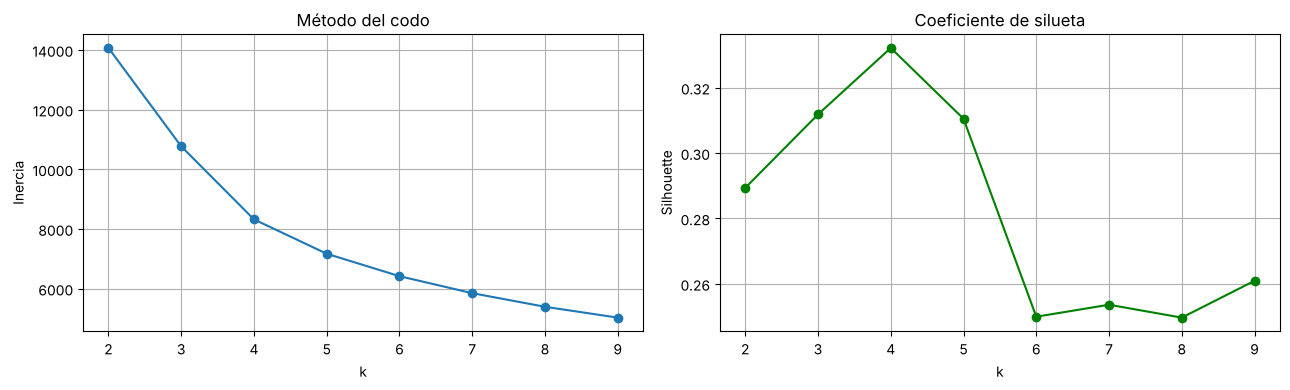

In [34]:
Z = X_pca[:, :n_components]

inertias = []
sil_scores = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(Z)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Z, labels))

print(pd.DataFrame({"k": K, "inercia": np.round(inertias, 0), "silhouette": np.round(sil_scores, 3)}).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K, inertias, marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[0].grid(True)
axes[1].plot(K, sil_scores, marker="o", color="green")
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [35]:
k_best = K[int(np.argmax(sil_scores))]
kmeans = KMeans(n_clusters=k_best, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(Z)
print(f"Clusters asignados con k = {k_best}. Silhouette = {max(sil_scores):.3f}")

df_clusters = df_limpio.copy()
df_clusters["cluster"] = cluster_labels
df_clusters.to_csv("Alumnos_con_clusters.csv", index=False)
df_clusters["cluster"].value_counts().sort_index()

Clusters asignados con k = 4. Silhouette = 0.332


cluster
0     744
1    3105
2    1260
3     891
Name: count, dtype: int64

La inercia baja de forma suave sin un codo claro y la mejor silueta es baja (0.332 con k = 4; valores mayores a 0.5 indicarían grupos bien separados). Esto ya anticipa que los clusters no son grupos naturales. Aun así los visualizo y los perfilo.

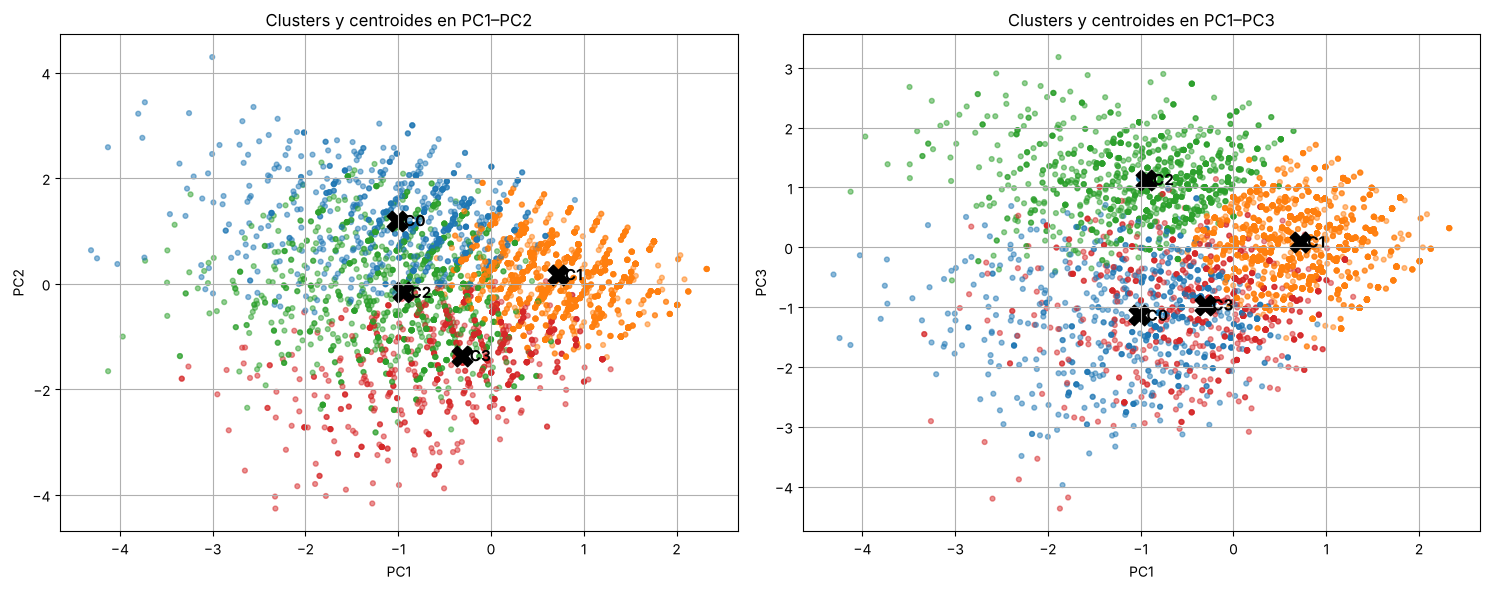

In [36]:
centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (i, j) in zip(axes, [(0, 1), (0, 2)]):
    ax.scatter(X_pca[:, i], X_pca[:, j], c=cluster_labels, s=12, alpha=0.5, cmap="tab10", vmin=0, vmax=9)
    ax.scatter(centroids[:, i], centroids[:, j], s=220, marker="X", c="black")
    for c, (cx, cy) in enumerate(zip(centroids[:, i], centroids[:, j])):
        ax.text(cx, cy, f"  C{c}", va="center", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"PC{i+1}")
    ax.set_ylabel(f"PC{j+1}")
    ax.set_title(f"Clusters y centroides en PC{i+1}–PC{j+1}")
    ax.grid(True)
plt.tight_layout()
plt.show()

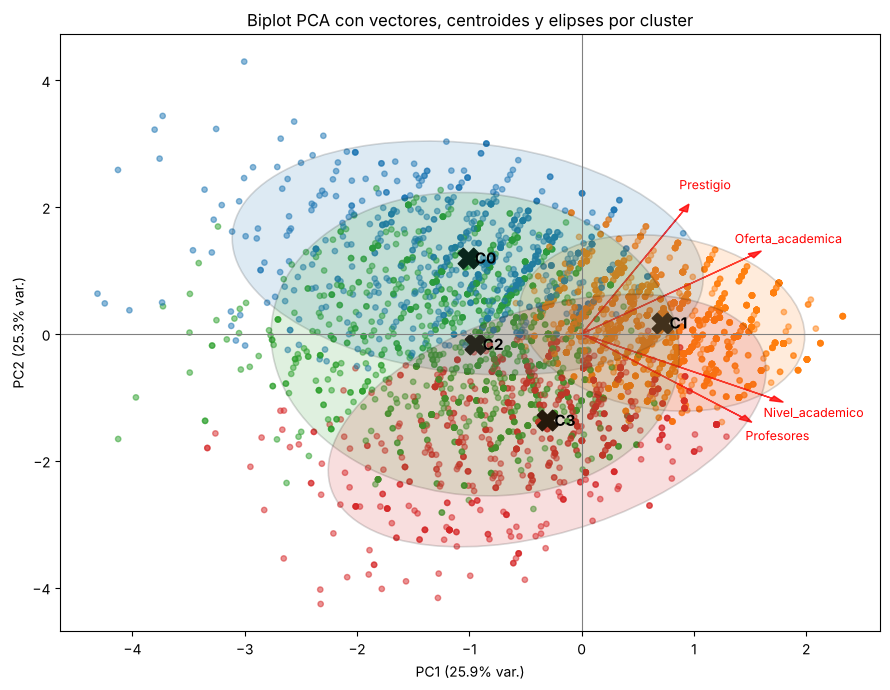

In [37]:
# ---------- Función para dibujar elipse (≈95% de confianza en 2D) ----------
def draw_cluster_ellipse(ax, pts, color, n_std=2.4477):
    mean = pts.mean(axis=0)
    cov = np.cov(pts, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  facecolor=color, edgecolor="black", alpha=0.15, lw=1.2)
    ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(9, 7))

# 1) Puntos coloreados por cluster
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=15, alpha=0.5, cmap="tab10", vmin=0, vmax=9)

# 2) Flechas (loadings)
for k, var in enumerate(variables):
    ax.arrow(0, 0, loadings.iloc[k, 0] * arrow_scale, loadings.iloc[k, 1] * arrow_scale,
             color="red", alpha=0.8, head_width=0.08, length_includes_head=True)
    ax.text(loadings.iloc[k, 0] * arrow_scale * 1.15, loadings.iloc[k, 1] * arrow_scale * 1.15,
            var, color="red", ha="center", va="center", fontsize=9)

# 3) Centroides
ax.scatter(centroids[:, 0], centroids[:, 1], s=220, marker="X", c="black")
for c, (cx, cy) in enumerate(centroids[:, :2]):
    ax.text(cx, cy, f"  C{c}", va="center", fontsize=11, fontweight="bold")

# 4) Elipses por cluster
colors = plt.cm.tab10(np.arange(k_best))
for c, color in zip(range(k_best), colors):
    draw_cluster_ellipse(ax, X_pca[cluster_labels == c, :2], color=color)

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel(f"PC1 ({explained_ratio[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({explained_ratio[1]*100:.1f}% var.)")
ax.set_title("Biplot PCA con vectores, centroides y elipses por cluster")
plt.tight_layout()
plt.show()

         Prestigio  Nivel_academico  Oferta_academica  Profesores  n_alumnos
cluster                                                                     
0             8.35             7.13              7.91        4.27        744
1             8.88             8.38              8.21        8.38       3105
2             8.62             6.11              4.65        8.18       1260
3             5.47             8.32              7.26        8.04        891


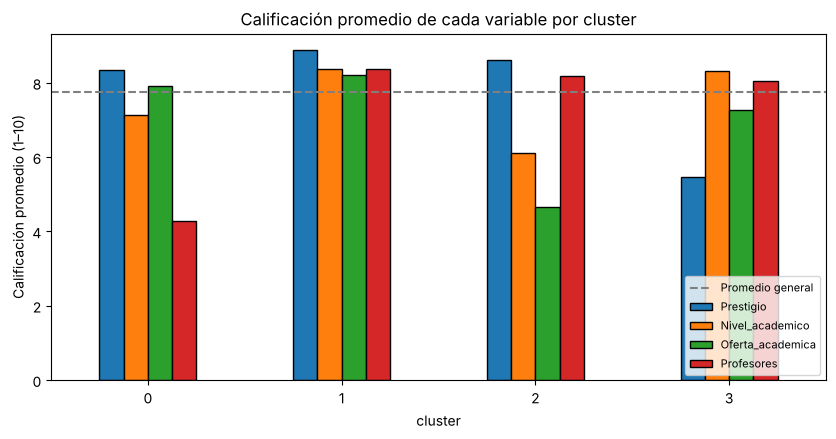

In [38]:
# Perfil de cada cluster con las variables originales
perfil = df_clusters.groupby("cluster")[variables].mean().round(2)
perfil["n_alumnos"] = df_clusters["cluster"].value_counts().sort_index()
print(perfil)

perfil[variables].plot(kind="bar", figsize=(10, 4.5), edgecolor="black")
plt.axhline(df_clusters[variables].mean().mean(), color="gray", linestyle="--", label="Promedio general")
plt.title("Calificación promedio de cada variable por cluster")
plt.ylabel("Calificación promedio (1–10)")
plt.xticks(rotation=0)
plt.legend(loc="lower right", fontsize=8)
plt.show()

**Interpretación de los clusters:**

| Cluster | Alumnos | Perfil | Nombre |
|---|---|---|---|
| 1 | 3,105 (52%) | Califica alto todo (8.2 a 8.9) | **Satisfechos** |
| 2 | 1,260 (21%) | Oferta académica muy baja (4.65) y nivel académico bajo (6.11) | **Inconformes con la oferta** |
| 3 | 891 (15%) | Prestigio bajo (5.47), lo demás bien | **Dudan del prestigio** |
| 0 | 744 (12%) | Profesores muy bajo (4.27) | **Inconformes con los profesores** |

Algo que llama la atención es que cada cluster "débil" se define por **una sola variable baja** mientras las demás siguen altas. Esto es consistente con lo que encontró el PCA: como las variables son independientes, un alumno puede calificar mal un atributo sin que eso afecte a los demás.

En las gráficas de clusters y en el biplot con elipses se ve que K-Means "corta" una sola nube continua: las elipses se enciman y no hay espacios vacíos entre grupos. Estos clusters pueden servir como una **partición práctica** para dirigir mensajes (por ejemplo, reforzar la comunicación sobre la oferta de carreras con el cluster que la califica bajo), pero son divisiones forzadas y no segmentos naturales. **Reducción o estructura de datos no es lo mismo que segmentación.**

## 10) Conclusiones y aplicación al negocio

- **Resultado principal:** el PCA no logra reducir la dimensionalidad. Los cuatro componentes explican entre 24% y 26% de la varianza cada uno, la prueba de Bartlett no es significativa y el análisis paralelo no retiene ningún componente. Las cuatro calificaciones miden aspectos **independientes** de la percepción.
- **Aplicación práctica:** no se puede resumir la evaluación de una universidad en una sola "calificación global"; cada atributo (prestigio, nivel académico, oferta y profesores) debe medirse y comunicarse por separado. Mejorar la imagen de prestigio no mejora automáticamente la percepción de los profesores o de la oferta.
- **Segmentación:** los clusters obtenidos sobre los componentes tienen una silueta baja y no corresponden a la universidad ni a la región; sirven como partición práctica para campañas, no como segmentos reales.
- **Uso en modelos:** como las variables no son redundantes, si se usan en un modelo predictivo o de clustering conviene usar las 4 variables originales estandarizadas en lugar de los componentes.
- **Limitaciones:** (1) una gran parte de los valores parece haber sido rellenada (8.4, 7.8 y probablemente el 8), lo que reduce la varianza y puede ocultar correlaciones reales; (2) las calificaciones son ordinales (1 a 10) y el PCA las trata como continuas; (3) solo hay 4 variables, por lo que el margen para reducir es pequeño; (4) los componentes son inestables; (5) el PCA describe la estructura de los datos, **no implica causalidad** ni crea segmentos por sí mismo.

---
## EXTRA (adicional a lo que pide la actividad): ¿los clusters dependen de la universidad evaluada?

**Esto es algo extra.** Para saber si los segmentos sirven para diferenciar a las universidades (por ejemplo, si los alumnos que evalúan al ITESM caen más en algún cluster), cruzo los clusters con la universidad evaluada y aplico una prueba **chi-cuadrada de independencia** (H0: el cluster no depende de la universidad).

Chi-cuadrada = 16.07, gl = 9, p-valor = 0.065
cluster         0     1     2     3
Universidad                        
ANÁHUAC      10.1  53.5  23.2  13.1
ITESM        13.9  48.2  19.3  18.5
OTRAS        12.4  51.5  21.3  14.7
UVM          10.8  58.1  18.8  12.4


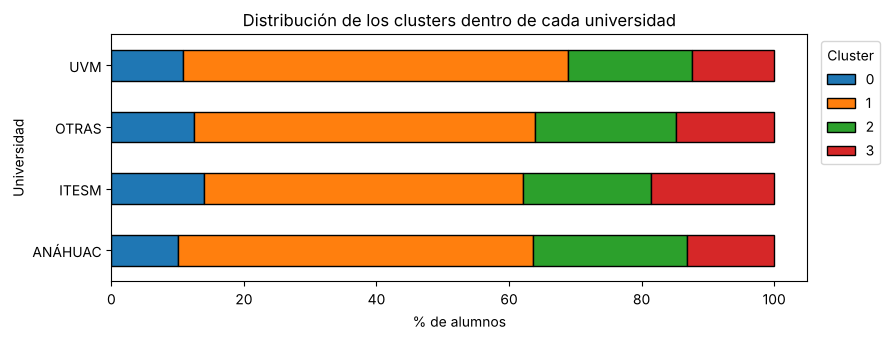

In [39]:
tabla = pd.crosstab(df_clusters["Universidad"], df_clusters["cluster"])
chi2_c, p_c, gl_c, _ = stats.chi2_contingency(tabla)
print(f"Chi-cuadrada = {chi2_c:.2f}, gl = {gl_c}, p-valor = {p_c:.3f}")

porcentajes = pd.crosstab(df_clusters["Universidad"], df_clusters["cluster"], normalize="index") * 100
print(porcentajes.round(1))

porcentajes.plot(kind="barh", stacked=True, figsize=(9, 3.5), color=plt.cm.tab10(np.arange(k_best)), edgecolor="black")
plt.xlabel("% de alumnos")
plt.title("Distribución de los clusters dentro de cada universidad")
plt.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretación del extra:** el p-valor es 0.065 (> 0.05), así que **no se rechaza H0**: la distribución de los clusters es prácticamente la misma en las cuatro universidades (en todas, alrededor de la mitad de los alumnos está en el cluster de "Satisfechos" y el resto se reparte de forma parecida). Las pequeñas diferencias (por ejemplo, UVM con 58% de satisfechos o ITESM con 18.5% en "Dudan del prestigio") no son estadísticamente significativas. Esto confirma, desde otro ángulo, que la percepción de los alumnos no depende de qué universidad evalúan, sino de cada alumno, por lo que los segmentos sirven para personalizar mensajes a alumnos y no para distinguir universidades.